# Used Car Price Prediction

## Exploratory Data Analysis (EDA)

The goal of this project is to develop a **machine learning regression model** that predicts the price of a used car in US dollars (`priceUSD`) based on its characteristics.

The dataset contains information about used cars, including:

- **make** – car manufacturer
- **model** – car model
- **year** – year of production
- **condition** – vehicle condition
- **mileage(kilometers)** – vehicle mileage
- **fuel_type** – type of fuel
- **volume(cm3)** – engine volume
- **color** – vehicle color
- **transmission** – transmission type
- **drive_unit** – drive type
- **segment** – vehicle segment
- **priceUSD** – vehicle price in US dollars and the **target variable**

Since the target variable (`priceUSD`) is a continuous numerical value, this is a **regression problem**.

### EDA Objective

The purpose of this notebook is to explore and understand the dataset before proceeding with data cleaning, feature engineering, preprocessing, and model training.

The analysis will focus on the structure of the dataset, data types, missing and duplicate values, distributions of numerical and categorical features, potential outliers, and relationships between vehicle characteristics and the target variable.

## 1. Import Libraries and Load the Dataset

In [19]:
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path("../data/cars.csv")

df = pd.read_csv(DATA_PATH)

## 2. Initial Data Inspection

Before performing data cleaning or preprocessing, the dataset is inspected to understand its basic structure and content.

The first rows and a random sample of observations are displayed to get an initial overview of the data. The dataset dimensions, column names, data types, and non-null values are also examined.

This initial inspection helps identify potential data quality issues and determines which variables require further analysis.

In [20]:
df.head(10)

,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
0,mazda,2,5500,2008,with mileage,162000.0,petrol,1500.0,burgundy,mechanics,front-wheel drive,B
1,mazda,2,5350,2009,with mileage,120000.0,petrol,1300.0,black,mechanics,front-wheel drive,B
2,mazda,2,7000,2009,with mileage,61000.0,petrol,1500.0,silver,auto,front-wheel drive,B
3,mazda,2,3300,2003,with mileage,265000.0,diesel,1400.0,white,mechanics,front-wheel drive,B
4,mazda,2,5200,2008,with mileage,97183.0,diesel,1400.0,gray,mechanics,front-wheel drive,B
5,mazda,2,3400,2005,with mileage,150000.0,petrol,1300.0,blue,mechanics,front-wheel drive,B
6,mazda,2,5000,2008,with mileage,112000.0,petrol,1300.0,gray,mechanics,front-wheel drive,B
7,mazda,2,7300,2009,with mileage,95000.0,petrol,1500.0,other,auto,front-wheel drive,B
8,mazda,2,6400,2010,with mileage,93804.0,petrol,1500.0,other,mechanics,front-wheel drive,B
9,mazda,2,6132,2008,with mileage,196511.0,petrol,1500.0,other,auto,front-wheel drive,B


In [21]:
df.sample(5, random_state=42)

,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
19270,mitsubishi,carisma,2050,1999,with mileage,250000.0,petrol,1800.0,blue,mechanics,front-wheel drive,M
25927,ford,fusion,4500,2006,with mileage,160000.0,petrol,1400.0,burgundy,mechanics,front-wheel drive,M
23388,mercedes-benz,e-klass,3500,1999,with mileage,485000.0,diesel,2900.0,blue,mechanics,rear drive,E
53189,bmw,x3,21000,2013,with mileage,159000.0,diesel,2000.0,black,auto,NaN,J
34058,renault,megane,3990,2002,with mileage,331700.0,diesel,1900.0,other,mechanics,front-wheel drive,C


In [22]:
df.shape

(56244, 12)

In [23]:
df.columns.tolist()

['make',
 'model',
 'priceUSD',
 'year',
 'condition',
 'mileage(kilometers)',
 'fuel_type',
 'volume(cm3)',
 'color',
 'transmission',
 'drive_unit',
 'segment']

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56244 entries, 0 to 56243
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make                 56244 non-null  str    
 1   model                56244 non-null  str    
 2   priceUSD             56244 non-null  int64  
 3   year                 56244 non-null  int64  
 4   condition            56244 non-null  str    
 5   mileage(kilometers)  56244 non-null  float64
 6   fuel_type            56244 non-null  str    
 7   volume(cm3)          56197 non-null  float64
 8   color                56244 non-null  str    
 9   transmission         56244 non-null  str    
 10  drive_unit           54339 non-null  str    
 11  segment              50953 non-null  str    
dtypes: float64(2), int64(2), str(8)
memory usage: 5.1 MB


## 3. Data Quality Assessment

The next step is to examine the dataset for potential data quality issues. This includes checking for **missing values**, **duplicate records**, and reviewing descriptive statistics for both numerical and categorical variables.

These checks will help determine which cleaning steps are necessary before the data is used for feature engineering, preprocessing, and model training.

In [25]:
# check missing values
df.isna().sum()

make                      0
model                     0
priceUSD                  0
year                      0
condition                 0
mileage(kilometers)       0
fuel_type                 0
volume(cm3)              47
color                     0
transmission              0
drive_unit             1905
segment                5291
dtype: int64

In [26]:
# check duplicate rows
df.duplicated().sum()

np.int64(87)

In [27]:
# descriptive statistics for numerical columns
df.describe()

,priceUSD,year,mileage(kilometers),volume(cm3)
count,56244.000000,56244.000000,5.624400e+04,56197.000000
mean,7415.456440,2003.454840,2.443956e+05,2104.860615
std,8316.959261,8.144247,3.210307e+05,959.201633
min,48.000000,1910.000000,0.000000e+00,500.000000
25%,2350.000000,1998.000000,1.370000e+05,1600.000000
50%,5350.000000,2004.000000,2.285000e+05,1996.000000
75%,9807.500000,2010.000000,3.100000e+05,2300.000000
max,235235.000000,2019.000000,9.999999e+06,20000.000000


In [28]:
# descriptive statistics for categorical columns
df.describe(include="object")

C:\Users\Korisnik\AppData\Local\Temp\ipykernel_16844\3667559729.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,make,model,condition,fuel_type,color,transmission,drive_unit,segment
count,56244,56244,56244,56244,56244,56244,54339,50953
unique,96,1034,3,3,13,2,4,9
top,volkswagen,passat,with mileage,petrol,black,mechanics,front-wheel drive,D
freq,6861,2086,55278,36405,12385,36056,38016,12605


## 4. Target Variable Analysis

The target variable for this regression problem is **`priceUSD`**, which represents the price of a used car in US dollars.

Before developing the regression model, it is important to examine the distribution of the target variable and identify potential extreme values or unusual patterns. A highly skewed target distribution or the presence of significant outliers may affect model performance and influence later data cleaning and modeling decisions.

In [29]:
df['priceUSD'].head()

0    5500
1    5350
2    7000
3    3300
4    5200
Name: priceUSD, dtype: int64

In [30]:
df['priceUSD'].dtype

dtype('int64')

### Target Variable Distribution

The distribution of `priceUSD` is examined using a histogram and a boxplot.

The histogram provides insight into the overall shape and spread of used car prices, while the boxplot helps identify potential extreme values and outliers. Since unusually high or low prices may either represent valid observations or data quality issues, these values will be investigated before making any cleaning decisions.

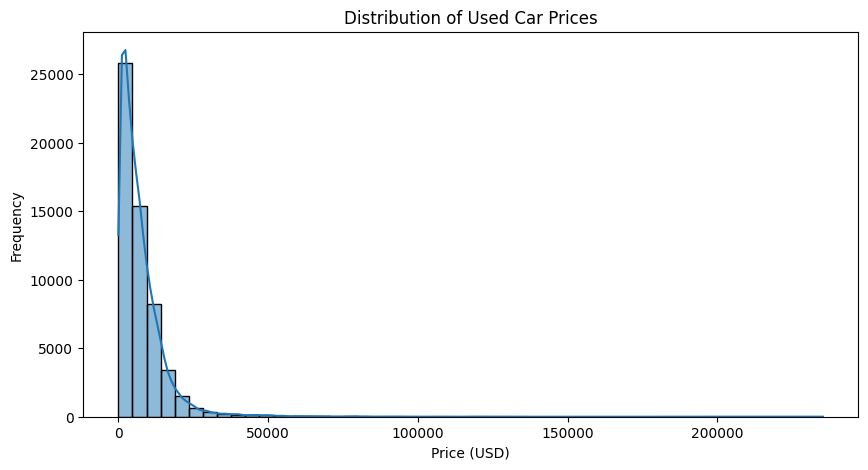

In [31]:
plt.figure(figsize=(10, 5))
sns.histplot(df["priceUSD"], bins=50, kde=True)

plt.title("Distribution of Used Car Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.show()

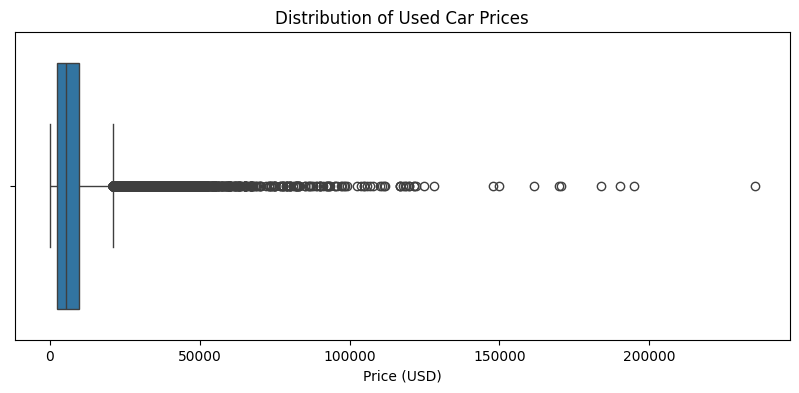

In [32]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["priceUSD"])

plt.title("Distribution of Used Car Prices")
plt.xlabel("Price (USD)")
plt.show()

### Target Variable Findings

The distribution of `priceUSD` is strongly **right-skewed**. Most used cars are concentrated in the lower price range, while a relatively small number of vehicles have substantially higher prices, creating a long right tail.

The boxplot also shows a large number of potential high-price outliers. However, these observations should not automatically be treated as errors, since large price differences can be realistic in the used car market and may reflect differences in vehicle make, model, age, condition, or other characteristics.

The median price is approximately **$5,350**, while the mean price is approximately **$7,416**. The higher mean compared with the median is consistent with the observed right-skewed distribution.

Potential extreme values will be investigated further before deciding whether any observations should be removed or transformed.

## 5. Feature Type Identification

Before analyzing the individual features, the dataset is divided into **numerical** and **categorical** variables based on their data types.

This distinction is important because numerical and categorical features require different approaches during exploratory analysis and later during data preprocessing.

The target variable (`priceUSD`) is excluded from the numerical feature list because it represents the value that the regression model will predict.

In [33]:
numerical_features = df.select_dtypes(include="number").columns.drop("priceUSD").tolist()

categorical_features = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['year', 'mileage(kilometers)', 'volume(cm3)']

Categorical features:
['make', 'model', 'condition', 'fuel_type', 'color', 'transmission', 'drive_unit', 'segment']


## 6. Categorical Feature Analysis

Categorical features are inspected to understand the number and frequency of their unique values and to identify potential inconsistencies that may require cleaning.

This analysis can reveal issues such as inconsistent capitalization, spelling variations, unexpected categories, or missing values represented in different ways.

The `model` feature is excluded from the full frequency output due to its high cardinality and is examined separately when necessary.

In [34]:
df[categorical_features].nunique().sort_values(ascending=False)

model           1034
make              96
color             13
segment            9
drive_unit         4
condition          3
fuel_type          3
transmission       2
dtype: int64

In [35]:
for column in categorical_features:
    if column != "model":
        print(f"\n--- {column} ---")
        print(df[column].value_counts(dropna=False))


--- make ---
make
volkswagen    6861
audi          4030
bmw           4013
opel          3779
renault       3713
              ... 
trabant          1
jac              1
asia             1
tagaz            1
saipa            1
Name: count, Length: 96, dtype: int64

--- condition ---
condition
with mileage    55278
with damage       512
for parts         454
Name: count, dtype: int64

--- fuel_type ---
fuel_type
petrol        36405
diesel        19792
electrocar       47
Name: count, dtype: int64

--- color ---
color
black       12385
silver      10075
blue         8083
gray         5807
white        5292
green        3911
other        3397
red          2744
burgundy     2026
brown        1349
purple        625
yellow        317
orange        233
Name: count, dtype: int64

--- transmission ---
transmission
mechanics    36056
auto         20188
Name: count, dtype: int64

--- drive_unit ---
drive_unit
front-wheel drive             38016
rear drive                     6836
all-wheel drive

In [36]:
low_cardinality_features = [
    "condition",
    "fuel_type",
    "color",
    "transmission",
    "drive_unit",
    "segment"
]

for column in low_cardinality_features:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- condition ---
condition
with mileage    55278
with damage       512
for parts         454
Name: count, dtype: int64

--- fuel_type ---
fuel_type
petrol        36405
diesel        19792
electrocar       47
Name: count, dtype: int64

--- color ---
color
black       12385
silver      10075
blue         8083
gray         5807
white        5292
green        3911
other        3397
red          2744
burgundy     2026
brown        1349
purple        625
yellow        317
orange        233
Name: count, dtype: int64

--- transmission ---
transmission
mechanics    36056
auto         20188
Name: count, dtype: int64

--- drive_unit ---
drive_unit
front-wheel drive             38016
rear drive                     6836
all-wheel drive                5890
part-time four-wheel drive     3597
NaN                            1905
Name: count, dtype: int64

--- segment ---
segment
D      12605
C      10617
J       8629
M       6313
E       6274
NaN     5291
B       4393
F        896
S        765
A    

## 7. Additional Data Quality Checks

Before data cleaning, extreme numerical values and production years are inspected to identify potentially invalid or unrealistic observations.

In [39]:
# extreme price values
print("Minimum price:", df["priceUSD"].min())
print("Maximum price:", df["priceUSD"].max())

# extreme mileage values
print("Minimum mileage:", df["mileage(kilometers)"].min())
print("Maximum mileage:", df["mileage(kilometers)"].max())

# production year range
print("Oldest year:", df["year"].min())
print("Newest year:", df["year"].max())

Minimum price: 48
Maximum price: 235235
Minimum mileage: 0.0
Maximum mileage: 9999999.0
Oldest year: 1910
Newest year: 2019
